Gradient Descent is a fundamental optimization algorithm used in machine learning and deep learning to minimize a function (usually a cost or loss function). 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5])    # features
y = np.array([2, 4, 6, 8, 10])   # labels

# Initialize parameters
theta0 = 0
theta1 = 0
alpha = 0.01       # learning rate
iterations = 1000
m = len(X)

# Gradient Descent
for _ in range(iterations):
    prediction = theta0 + theta1 * X
    error = prediction - y
    
    # Gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)
    
    # Update parameters
    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

# Final parameters
print(f"theta0: {theta0}, theta1: {theta1}")

theta0: 0.09475321533750963, theta1: 1.9737548787242036


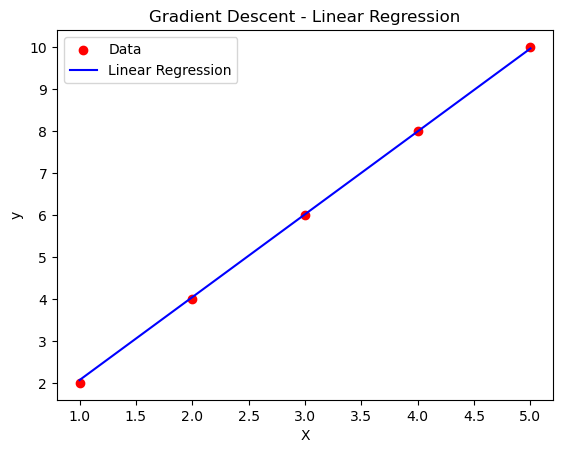

In [2]:
# Plotting the line
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Linear Regression')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Gradient Descent - Linear Regression")
plt.show()

# Stochastic Gradient Descent (SGD)
Stochastic Gradient Descent (SGD) is a variation of gradient descent where parameters are updated using only one training example at a time. It's especially useful for large datasets because it updates faster and can escape local minima due to its randomness. SGD computes gradients on individual data points, updating parameters more frequently. It is widely used in ML due to its efficiency with large datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize parameters
theta0 = 0
theta1 = 0
alpha = 0.01
epochs = 50

m = len(X)

# SGD loop
for epoch in range(epochs):
    for i in range(m):
        xi = X[i]
        yi = y[i]

        prediction = theta0 + theta1 * xi
        error = prediction - yi

        # Gradient update
        theta0 -= alpha * error
        theta1 -= alpha * error * xi

    # Optional: print loss every 10 epochs
    if epoch % 10 == 0:
        total_loss = np.mean((theta0 + theta1 * X - y) ** 2)
        print(f"Epoch {epoch}: Loss = {total_loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Epoch 0: Loss = 11.7767
Epoch 10: Loss = 0.0442
Epoch 20: Loss = 0.0373
Epoch 30: Loss = 0.0314
Epoch 40: Loss = 0.0263

Final theta0: 0.3489092640282627, theta1: 1.9104971363782433


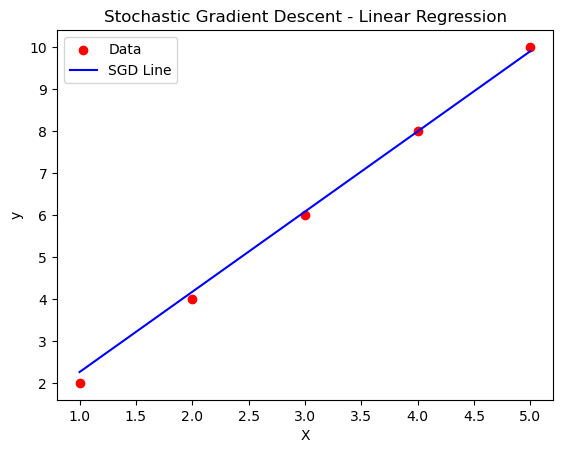

In [2]:
# Plotting results
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='SGD Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Stochastic Gradient Descent - Linear Regression")
plt.show()

# Momentum-based Gradient Descent
Momentum-based Gradient Descent is an enhanced version of standard gradient descent that helps accelerate convergence and smooth out the updates — especially useful when the loss surface has ravines (i.e., areas where the slope in one dimension is steeper than in others). Momentum adds an exponentially weighted moving average of past
gradients to the current update, improving convergence speed and stability.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize parameters
theta0 = 0
theta1 = 0
alpha = 0.01
beta = 0.9
iterations = 100

# Initialize momentum terms
v_theta0 = 0
v_theta1 = 0

m = len(X)

# Gradient Descent with Momentum
for i in range(iterations):
    prediction = theta0 + theta1 * X
    error = prediction - y

    # Compute gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Update momentum terms
    v_theta0 = beta * v_theta0 + (1 - beta) * d_theta0
    v_theta1 = beta * v_theta1 + (1 - beta) * d_theta1

    # Update parameters
    theta0 -= alpha * v_theta0
    theta1 -= alpha * v_theta1

    # Optional: print loss
    if i % 10 == 0:
        loss = np.mean((prediction - y) ** 2)
        print(f"Iteration {i}: Loss = {loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 0: Loss = 44.0000
Iteration 10: Loss = 13.7789
Iteration 20: Loss = 0.0578
Iteration 30: Loss = 1.5374
Iteration 40: Loss = 0.7409
Iteration 50: Loss = 0.0561
Iteration 60: Loss = 0.0860
Iteration 70: Loss = 0.0718
Iteration 80: Loss = 0.0397
Iteration 90: Loss = 0.0377

Final theta0: 0.44312342915954, theta1: 1.8886607966213385


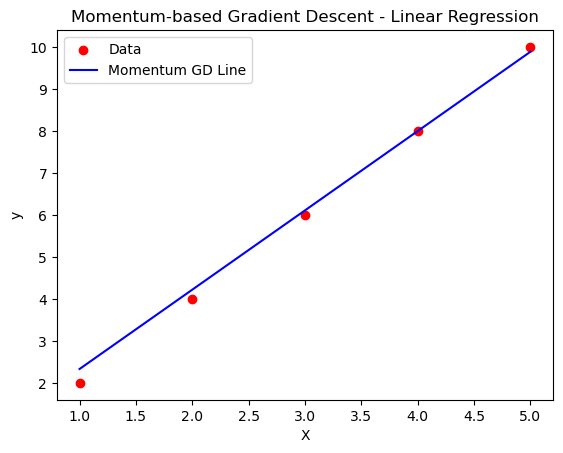

In [4]:
# Plotting
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Momentum GD Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Momentum-based Gradient Descent - Linear Regression")
plt.show()

# Nesterov Accelerated Gradient (NAG)
NAG improves upon momentum by calculating gradients at a lookahead position, resulting in more precise updates.In standard momentum, you update based on the past velocity. But with Nesterov, you peek ahead to where the momentum is going before computing the gradient

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize parameters
theta0 = 0
theta1 = 0
alpha = 0.01  # Learning rate
beta = 0.9    # Momentum factor
iterations = 100

# Initialize velocities
v_theta0 = 0
v_theta1 = 0

m = len(X)

# NAG Gradient Descent
for i in range(iterations):
    # Look ahead step
    temp_theta0 = theta0 - beta * v_theta0
    temp_theta1 = theta1 - beta * v_theta1

    # Compute gradients at lookahead position
    prediction = temp_theta0 + temp_theta1 * X
    error = prediction - y

    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Update velocities
    v_theta0 = beta * v_theta0 + alpha * d_theta0
    v_theta1 = beta * v_theta1 + alpha * d_theta1

    # Update parameters
    theta0 -= v_theta0
    theta1 -= v_theta1

    # Optional: print loss
    if i % 10 == 0:
        loss = np.mean((theta0 + theta1 * X - y) ** 2)
        print(f"Iteration {i}: Loss = {loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 0: Loss = 34.2152
Iteration 10: Loss = 2.6511
Iteration 20: Loss = 0.1768
Iteration 30: Loss = 0.0259
Iteration 40: Loss = 0.0145
Iteration 50: Loss = 0.0098
Iteration 60: Loss = 0.0065
Iteration 70: Loss = 0.0043
Iteration 80: Loss = 0.0029
Iteration 90: Loss = 0.0019

Final theta0: 0.08499093584245893, theta1: 1.976478073709542


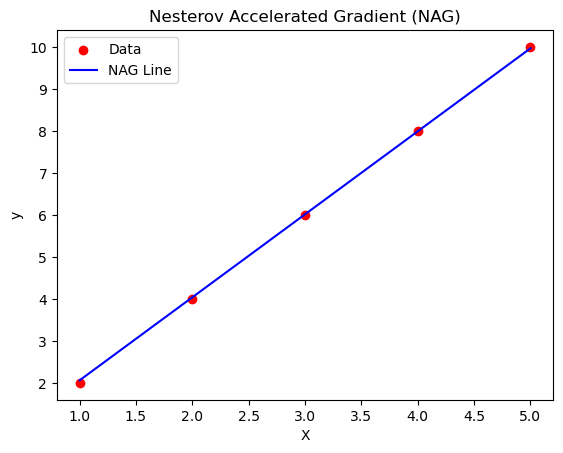

In [6]:
# Plot results
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='NAG Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Nesterov Accelerated Gradient (NAG)")
plt.show()